In [5]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/all-data/Fin_dataset/Autistic/0664.jpg
/kaggle/input/all-data/Fin_dataset/Autistic/1269.jpg
/kaggle/input/all-data/Fin_dataset/Autistic/0733.jpg
/kaggle/input/all-data/Fin_dataset/Autistic/Copy of Autistic.399.jpg
/kaggle/input/all-data/Fin_dataset/Autistic/Copy of Copy of Autistic.200.jpg
/kaggle/input/all-data/Fin_dataset/Autistic/0106.jpg
/kaggle/input/all-data/Fin_dataset/Autistic/0375.jpg
/kaggle/input/all-data/Fin_dataset/Autistic/1075.jpg
/kaggle/input/all-data/Fin_dataset/Autistic/0285.jpg
/kaggle/input/all-data/Fin_dataset/Autistic/Autistic1 (70).png
/kaggle/input/all-data/Fin_dataset/Autistic/0591.jpg
/kaggle/input/all-data/Fin_dataset/Autistic/Autistic1 (1).png
/kaggle/input/all-data/Fin_dataset/Autistic/0799.jpg
/kaggle/input/all-data/Fin_dataset/Autistic/1411.jpg
/kaggle/input/all-data/Fin_dataset/Autistic/0074.jpg
/kaggle/input/all-data/Fin_dataset/Autistic/1031.jpg
/kaggle/input/all-data/Fin_dataset/Autistic/Autistic1 (4).png
/kaggle/input/all-data/Fin_data

In [1]:
import os
import cv2
import dlib
import numpy as np
from imutils import face_utils

def align_face(image, predictor, detector, output_size, background_color):
    """
    Aligns the face in the given image.
    If no face is detected, returns None.
    """
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    rects = detector(gray, 0)
    
    if len(rects) == 0:
        print("No face detected during alignment.")
        return None

    # Process only the first detected face
    rect = rects[0]
    shape = predictor(gray, rect)
    shape = face_utils.shape_to_np(shape)

    (lStart, lEnd) = face_utils.FACIAL_LANDMARKS_IDXS["left_eye"]
    (rStart, rEnd) = face_utils.FACIAL_LANDMARKS_IDXS["right_eye"]
    leftEyePts = shape[lStart:lEnd]
    rightEyePts = shape[rStart:rEnd]

    leftEyeCenter = leftEyePts.mean(axis=0).astype("int")
    rightEyeCenter = rightEyePts.mean(axis=0).astype("int")

    dY = rightEyeCenter[1] - leftEyeCenter[1]
    dX = rightEyeCenter[0] - leftEyeCenter[0]
    angle = np.degrees(np.arctan2(dY, dX))

    if angle > 90:
        angle -= 180
    elif angle < -90:
        angle += 180

    # print("Normalized angle:", angle)
    face_center = ((rect.left() + rect.right()) // 2, (rect.top() + rect.bottom()) // 2)
    
    output_w, output_h = output_size
    M = cv2.getRotationMatrix2D(face_center, angle, 1.0)
    # Adjust the transformation matrix so the face is centered
    M[0, 2] += (output_w / 2) - face_center[0]
    M[1, 2] += (output_h / 2) - face_center[1]

    rotated = cv2.warpAffine(image, M, (output_w, output_h), flags=cv2.INTER_CUBIC, borderValue=background_color)
    return rotated

def crop_face(image, predictor, detector):
    """
    Crops the facial region from an aligned image.
    If no face is detected, returns the original image.
    """
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    faces = detector(gray)

    if len(faces) == 0:
        print("No face detected during cropping. Returning the aligned (or original) image.")
        return image

    face = faces[0]
    landmarks = predictor(gray, face)

    # Gather key facial landmarks (jawline, eyebrows, eyes & mouth)
    face_points = np.array(
        [(landmarks.part(i).x, landmarks.part(i).y) for i in range(2, 15)] +
        [(landmarks.part(i).x, landmarks.part(i).y) for i in range(17, 27)] +
        [(landmarks.part(i).x, landmarks.part(i).y) for i in range(36, 48)]
    )

    # Compute convex hull for a tight boundary around the face
    hull = cv2.convexHull(face_points)

    # Create mask and extract only the face
    mask = np.zeros_like(gray)
    cv2.fillConvexPoly(mask, hull, 255)
    result = cv2.bitwise_and(image, image, mask=mask)

    # Create white background and combine with masked face
    bg = np.ones_like(image, dtype=np.uint8) * 255
    mask_inv = cv2.bitwise_not(mask)
    white_bg = cv2.bitwise_and(bg, bg, mask=mask_inv)
    final_image = cv2.add(result, white_bg)

    # Crop to the bounding box around the convex hull
    x, y, w, h = cv2.boundingRect(hull)
    cropped_face = final_image[y:y+h, x:x+w]
    return cropped_face

def process_image(image_path, predictor, detector, output_size, background_color):
    """
    Reads an image, attempts to align and crop the face.
    If face alignment fails, returns the original image.
    """
    image = cv2.imread(image_path)
    if image is None:
        print("Failed to read image:", image_path)
        return None
    
    # Try to align the face
    aligned = align_face(image, predictor, detector, output_size, background_color)
    
    if aligned is None:
        # If alignment failed, use the original image directly.
        print("Using original image as no face was aligned.")
        return image
    else:
        # Crop the face from the aligned image
        cropped = crop_face(aligned, predictor, detector)
        return cropped

def process_dataset(input_dataset_path, output_dataset_path, predictor_path, output_size_multiplier=2, background_color=(255, 255, 255)):
    """
    Processes all images in the input dataset folder.
    For each image, attempts to align then crop the face.
    The resulting image (or the original image if no face is detected) is saved to a new folder
    that mirrors the input folder structure (e.g. Autistic, Non-Autistic).
    """
    # Create dlib objects once for efficiency
    predictor = dlib.shape_predictor(predictor_path)
    detector = dlib.get_frontal_face_detector()
    
    # Loop over each subfolder (e.g., Autistic, Non-Autistic)
    for folder in os.listdir(input_dataset_path):
        folder_path = os.path.join(input_dataset_path, folder)
        if not os.path.isdir(folder_path):
            continue
        
        # Create the corresponding output folder
        output_folder = os.path.join(output_dataset_path, folder)
        os.makedirs(output_folder, exist_ok=True)
        
        # Process each image in the folder
        for filename in os.listdir(folder_path):
            if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
                image_path = os.path.join(folder_path, filename)
                image = cv2.imread(image_path)
                if image is None:
                    print("Skipping file (not an image):", image_path)
                    continue
                h, w = image.shape[:2]
                # Scale up the output size if needed (for example, double the dimensions)
                output_size = (w * output_size_multiplier, h * output_size_multiplier)
                processed = process_image(image_path, predictor, detector, output_size, background_color)
                if processed is None:
                    continue
                output_image_path = os.path.join(output_folder, filename)
                cv2.imwrite(output_image_path, processed)
                print("Processed and saved:", output_image_path)

# Example usage:
input_dataset_path = '/kaggle/input/all-data/Fin_dataset'
output_dataset_path = '/kaggle/working/processed_faces'
predictor_path = '/kaggle/input/dat-file/shape_predictor_68_face_landmarks.dat'

process_dataset(input_dataset_path, output_dataset_path, predictor_path)

Processed and saved: /kaggle/working/processed_faces/Autistic/0664.jpg
Processed and saved: /kaggle/working/processed_faces/Autistic/1269.jpg
Processed and saved: /kaggle/working/processed_faces/Autistic/0733.jpg
Processed and saved: /kaggle/working/processed_faces/Autistic/Copy of Autistic.399.jpg
Processed and saved: /kaggle/working/processed_faces/Autistic/Copy of Copy of Autistic.200.jpg
Processed and saved: /kaggle/working/processed_faces/Autistic/0106.jpg
Processed and saved: /kaggle/working/processed_faces/Autistic/0375.jpg
Processed and saved: /kaggle/working/processed_faces/Autistic/1075.jpg
Processed and saved: /kaggle/working/processed_faces/Autistic/0285.jpg
Processed and saved: /kaggle/working/processed_faces/Autistic/Autistic1 (70).png
No face detected during alignment.
Using original image as no face was aligned.
Processed and saved: /kaggle/working/processed_faces/Autistic/0591.jpg
Processed and saved: /kaggle/working/processed_faces/Autistic/Autistic1 (1).png
Processed

In [2]:
# # Zip the folder
# !zip -r /kaggle/working/processed_faces.zip /kaggle/working/processed_faces

# # Create a link to download the zipped file
# from IPython.display import FileLink
# FileLink('/kaggle/working/processed_faces.zip')

  adding: kaggle/working/processed_faces/ (stored 0%)
  adding: kaggle/working/processed_faces/Non-Autistic/ (stored 0%)
  adding: kaggle/working/processed_faces/Non-Autistic/1285.jpg (deflated 2%)
  adding: kaggle/working/processed_faces/Non-Autistic/0296.jpg (deflated 1%)
  adding: kaggle/working/processed_faces/Non-Autistic/non autistic1 (18).jpg (deflated 1%)
  adding: kaggle/working/processed_faces/Non-Autistic/0518.jpg (deflated 1%)
  adding: kaggle/working/processed_faces/Non-Autistic/0891.jpg (deflated 2%)
  adding: kaggle/working/processed_faces/Non-Autistic/1390.jpg (deflated 2%)
  adding: kaggle/working/processed_faces/Non-Autistic/0183.jpg (deflated 1%)
  adding: kaggle/working/processed_faces/Non-Autistic/0435.jpg (deflated 2%)
  adding: kaggle/working/processed_faces/Non-Autistic/0730.jpg (deflated 2%)
  adding: kaggle/working/processed_faces/Non-Autistic/0033.jpg (deflated 3%)
  adding: kaggle/working/processed_faces/Non-Autistic/1398.jpg (deflated 2%)
  adding: kaggle/w

/kaggle/working/processed_faces.zip

In [6]:
# image_path = "/kaggle/input/all-data/Fin_dataset/Autistic/0014.jpg"

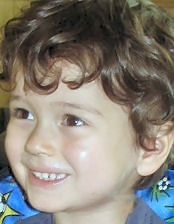

In [7]:
# from IPython.display import Image
# Image(filename=image_path)

In [ ]:
# import cv2
# import numpy as np
# import matplotlib.pyplot as plt

# # Path to your input image
# input_image_path = "/kaggle/input/all-data/Fin_dataset/Autistic/0007.jpg"

# # Read the image in color (default mode)
# image = cv2.imread(input_image_path)
# if image is None:
#     raise IOError(f"Could not open or find the image: {input_image_path}")

# # Define a sharpening kernel.
# kernel = np.array([[ 0, -1,  0],
#                    [-1,  5, -1],
#                    [ 0, -1,  0]])

# # Apply the kernel to the input image using filter2D.
# # The filter is applied to each channel.
# sharpened = cv2.filter2D(image, -1, kernel)

# # Convert images from BGR to RGB for correct color display in matplotlib
# image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
# sharpened_rgb = cv2.cvtColor(sharpened, cv2.COLOR_BGR2RGB)

# # Display the original and sharpened images inline using matplotlib
# plt.figure(figsize=(12, 6))

# plt.subplot(1, 2, 1)
# plt.imshow(image_rgb)
# plt.title("Original Image")
# plt.axis("off")

# plt.subplot(1, 2, 2)
# plt.imshow(sharpened_rgb)
# plt.title("Sharpened Image")
# plt.axis("off")

# plt.tight_layout()
# plt.show()

# cv2.imwrite('/kaggle/working/sharp_face.jpg', sharpened_rgb)

Normalized angle: 8.297144969836864


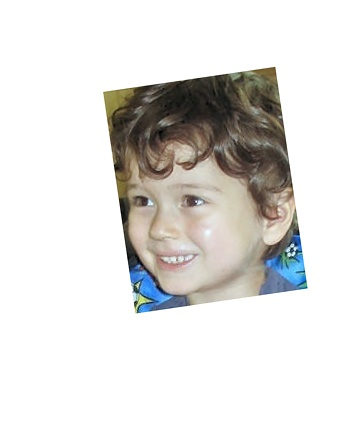

In [9]:
# import cv2
# import dlib
# import numpy as np
# from imutils import face_utils

# def align_face(image_path, predictor_path, output_size=None, background_color=(0, 0, 0)):
#     image = cv2.imread(image_path)
#     gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
#     detector = dlib.get_frontal_face_detector()
#     predictor = dlib.shape_predictor(predictor_path)
#     rects = detector(gray, 0)
    
#     if len(rects) == 0:
#         print("No face detected")
#         return image

#     # Process only the first detected face
#     for rect in rects:
#         shape = predictor(gray, rect)
#         shape = face_utils.shape_to_np(shape)

#         (lStart, lEnd) = face_utils.FACIAL_LANDMARKS_IDXS["left_eye"]
#         (rStart, rEnd) = face_utils.FACIAL_LANDMARKS_IDXS["right_eye"]
#         leftEyePts = shape[lStart:lEnd]
#         rightEyePts = shape[rStart:rEnd]

#         leftEyeCenter = leftEyePts.mean(axis=0).astype("int")
#         rightEyeCenter = rightEyePts.mean(axis=0).astype("int")

#         dY = rightEyeCenter[1] - leftEyeCenter[1]
#         dX = rightEyeCenter[0] - leftEyeCenter[0]
#         angle = np.degrees(np.arctan2(dY, dX))

#         if angle > 90:
#             angle -= 180
#         elif angle < -90:
#             angle += 180

#         print("Normalized angle:", angle)
#         face_center = ((rect.left() + rect.right()) // 2, (rect.top() + rect.bottom()) // 2)
        
#         if output_size is None:
#             output_size = (image.shape[1], image.shape[0])
#         output_w, output_h = output_size

#         M = cv2.getRotationMatrix2D(face_center, angle, 1.0)
#         M[0, 2] += (output_w / 2) - face_center[0]
#         M[1, 2] += (output_h / 2) - face_center[1]

#         rotated = cv2.warpAffine(image, M, (output_w, output_h), flags=cv2.INTER_CUBIC, borderValue=background_color)
#         return rotated

#     print("Face alignment failed")
#     return image

# # Define your paths
# image_path = "/kaggle/input/all-data/Fin_dataset/Autistic/0014.jpg"
# predictor_path = '/kaggle/input/dat-file/shape_predictor_68_face_landmarks.dat'

# # Read the image to get its dimensions for output_size
# img = cv2.imread(image_path)
# output_size = (img.shape[1]*2, img.shape[0]*2)

# output = align_face(
#     image_path,
#     predictor_path,
#     output_size=output_size,
#     background_color=(255, 255, 255)  # white background; change as needed
# )

# cv2.imwrite('/kaggle/working/aligned_face.jpg', output)

# from IPython.display import Image
# Image(filename='/kaggle/working/aligned_face.jpg')


Cropping complete. Check the cropped images in: /kaggle/working/crop.jpg


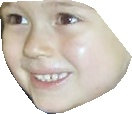

In [10]:
# import os
# import cv2
# import dlib
# import numpy as np

# # Load the pre-trained dlib face detector
# detector = dlib.get_frontal_face_detector()
# predictor = dlib.shape_predictor("/kaggle/input/dat-file/shape_predictor_68_face_landmarks.dat")  # Download required

# # # Paths to datasets
# # dataset = [
# #     ("/kaggle/input/autism-detection/Fin_dataset/Non-Autistic", "Non-Autistic"),
# #     ("/kaggle/input/autism-detection/Fin_dataset/Autistic", "Autistic"),
# # ]

# # # Create output directory
# # output_dir = "/kaggle/working/cropped_faces"
# # os.makedirs(output_dir, exist_ok=True)
# input_image_path = "/kaggle/working/aligned_face.jpg"
# output_path = "/kaggle/working/crop.jpg"

# def crop_face(image_path, output_path):
#     # Read image
#     image = cv2.imread(image_path)
#     gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

#     # Detect faces
#     faces = detector(gray)
#     face=faces[0]

   
#         # Detect facial landmarks
#     landmarks = predictor(gray, face)

#         # Extract only important facial keypoints (excluding ears and neck)
#     face_points = np.array([
#             (landmarks.part(i).x, landmarks.part(i).y) for i in range(2, 15)  # Jawline (no ears)
#         ] + [
#             (landmarks.part(i).x, landmarks.part(i).y) for i in range(17, 27)  # Eyebrows
#         ] + [
#             (landmarks.part(i).x, landmarks.part(i).y) for i in range(36, 48)  # Eyes & Mouth
#     ])

#         # Compute convex hull (tight boundary around selected points)
#     hull = cv2.convexHull(face_points)

#         # Create mask
#     mask = np.zeros_like(gray)
#     cv2.fillConvexPoly(mask, hull, 255)

#         # Apply mask to get only the face
#     result = cv2.bitwise_and(image, image, mask=mask)

#         # Convert masked region to white background
#     bg = np.ones_like(image, dtype=np.uint8) * 255  # White background
#     mask_inv = cv2.bitwise_not(mask)
#     white_bg = cv2.bitwise_and(bg, bg, mask=mask_inv)
#     final_image = cv2.add(result, white_bg)

#         # Crop bounding box around the hull
#     x, y, w, h = cv2.boundingRect(hull)
#     cropped_face = final_image[y:y+h, x:x+w]

#         # Save the cropped image
#     cv2.imwrite(output_path, cropped_face)

# # Process the first 5 images from each class
# # for folder, label in dataset:
# #     files = os.listdir(folder)[2:3]  # Get first 5 images

# #     for i, file in enumerate(files):
# #         file_path = os.path.join(folder, file)
# #         output_path = os.path.join(output_dir, f"{label}_{i}.jpg")
# #         crop_face(file_path, output_path)
# crop_face(input_image_path, output_path)

# print("Cropping complete. Check the cropped images in:", output_path)

# from IPython.display import Image
# Image(filename='/kaggle/working/crop.jpg')

In [ ]:
# import cv2
# import dlib
# import numpy as np
# from imutils import face_utils

# def align_face(image_path, predictor_path):
#     image = cv2.imread(image_path)
#     gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

#     detector = dlib.get_frontal_face_detector()
#     predictor = dlib.shape_predictor(predictor_path)

#     rects = detector(gray, 0)

#     if len(rects) == 0:
#         print("No face detected")
#         return image

#     for rect in rects:
#         shape = predictor(gray, rect)
#         shape = face_utils.shape_to_np(shape)

#         (lStart, lEnd) = face_utils.FACIAL_LANDMARKS_IDXS["left_eye"]
#         (rStart, rEnd) = face_utils.FACIAL_LANDMARKS_IDXS["right_eye"]
#         leftEyePts = shape[lStart:lEnd]
#         rightEyePts = shape[rStart:rEnd]

#         leftEyeCenter = leftEyePts.mean(axis=0).astype("int")
#         rightEyeCenter = rightEyePts.mean(axis=0).astype("int")

#         dY = rightEyeCenter[1] - leftEyeCenter[1]
#         dX = rightEyeCenter[0] - leftEyeCenter[0]
#         angle = np.degrees(np.arctan2(dY, dX))

#         if angle > 90:
#             angle -= 180
#         elif angle < -90:
#             angle += 180

#         print("Normalized angle:", angle)

#         face_center = ((rect.left() + rect.right()) // 2, (rect.top() + rect.bottom()) // 2)
        
#         h, w = image.shape[:2]
#         cos = np.abs(np.cos(np.radians(angle)))
#         sin = np.abs(np.sin(np.radians(angle)))
#         new_w = int((h * sin) + (w * cos))
#         new_h = int((h * cos) + (w * sin))

#         M = cv2.getRotationMatrix2D(face_center, angle, 1.0)
#         M[0, 2] += (new_w / 2) - face_center[0]
#         M[1, 2] += (new_h / 2) - face_center[1]

#         rotated = cv2.warpAffine(image, M, (new_w, new_h), flags=cv2.INTER_CUBIC)

#         return rotated

#     print("Face alignment failed")
#     return image

# output = align_face(
#     image_path,
#     '/kaggle/input/dat-file/shape_predictor_68_face_landmarks.dat'
# )

# cv2.imwrite('/kaggle/working/aligned_face.jpg', output)

# from IPython.display import Image
# Image(filename='/kaggle/working/aligned_face.jpg')

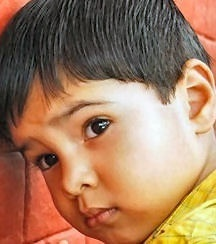

In [11]:
# from IPython.display import Image
# Image(filename='/kaggle/working/aligned_face.jpg')

In [ ]:
# import cv2
# import dlib
# import numpy as np
# from imutils import face_utils

# def crop_face(image_path, predictor_path):
#     # Load image
#     image = cv2.imread(image_path)
#     gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

#     # Initialize dlib's face detector and landmark predictor
#     detector = dlib.get_frontal_face_detector()
#     predictor = dlib.shape_predictor(predictor_path)

#     # Detect faces in the grayscale image
#     rects = detector(gray, 0)

#     if len(rects) == 0:
#         print("No face detected")
#         return None

#     for rect in rects:
#         # Get facial landmarks
#         shape = predictor(gray, rect)
#         shape = face_utils.shape_to_np(shape)

#         # Extract the face ROI
#         (x, y, w, h) = face_utils.rect_to_bb(rect)
        
#         # Crop the face from the original image
#         face_roi = image[y:y+h, x:x+w]

#         return face_roi

#     print("Face cropping failed")
#     return None

# # Run the cropping function
# output = crop_face(
#     '/kaggle/working/aligned_face.jpg',
#     '/kaggle/input/dat-file/shape_predictor_68_face_landmarks.dat'
# )

# if output is not None:
#     # Save the cropped face
#     cv2.imwrite('/kaggle/working/cropped_face.jpg', output)

#     # Display the result
#     from IPython.display import Image
#     Image(filename='/kaggle/working/cropped_face.jpg')
# else:
#     print("Failed to crop the face.")

In [ ]:
# import cv2
# import dlib
# import numpy as np

# # Paths to input image and output image
# input_image_path = "/kaggle/working/aligned_face.jpg"
# output_image_path = "/kaggle/working/crop.jpg"

# # Load the input image
# image = cv2.imread(input_image_path)
# if image is None:
#     raise IOError(f"Could not open or find the image: {input_image_path}")

# # Convert to grayscale for face detection
# gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# # Initialize dlib's face detector (HOG-based) and shape predictor
# detector = dlib.get_frontal_face_detector()

# # Download or place shape_predictor_68_face_landmarks.dat in the same folder
# # You can get it from: http://dlib.net/files/shape_predictor_68_face_landmarks.dat.bz2
# predictor_path = "/kaggle/input/dat-file/shape_predictor_68_face_landmarks.dat"
# predictor = dlib.shape_predictor(predictor_path)

# # Detect faces in the grayscale image
# faces = detector(gray)

# if len(faces) == 0:
#     print("No faces detected.")
#     exit()

# # For simplicity, just take the first detected face
# face = faces[0]

# # Predict the landmark points
# landmarks = predictor(gray, face)

# # Collect all (x, y) points in a list
# points = []
# for i in range(68):
#     x = landmarks.part(i).x
#     y = landmarks.part(i).y
#     points.append((x, y))

# # Convert to a NumPy array
# points_array = np.array(points, dtype=np.int32)

# # Compute a convex hull around the face landmarks to get the outer boundary
# hull = cv2.convexHull(points_array)

# # Create a mask where we fill in the face shape
# mask = np.zeros(image.shape[:2], dtype=np.uint8)
# cv2.fillConvexPoly(mask, hull, 255)

# # Extract just the face region using the mask
# face_only = cv2.bitwise_and(image, image, mask=mask)

# # (Optional) Create an RGBA image (add alpha channel for transparency)
# b, g, r = cv2.split(face_only)
# rgba = cv2.merge([b, g, r, mask])  # The mask is used as the alpha channel

# # Save the output with transparency
# cv2.imwrite(output_image_path, rgba)

# print("Face extraction complete! Saved to", output_image_path)


In [ ]:
import torch
from transformers import ViTForImageClassification, ViTImageProcessor
from transformers import AutoImageProcessor, AutoModelForImageClassification
from torchvision.datasets import ImageFolder
from torchvision.transforms import Compose, Resize, ToTensor, Normalize
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tqdm import tqdm

In [ ]:
model_name = "google/vit-base-patch16-224"
processor = AutoImageProcessor.from_pretrained(model_name,use_fast=True)
model = AutoModelForImageClassification.from_pretrained(model_name)

In [ ]:
def preprocess_data(data_dir):
    transform = Compose([
        Resize((224, 224)),
        ToTensor(),
        Normalize(mean=processor.image_mean, std=processor.image_std),
    ])
    dataset = ImageFolder(root=data_dir, transform=transform)
    return dataset

In [ ]:
# import os

# print(os.listdir("/kaggle/input/"))  # Check if 'autism-dataset' exists
# # print(os.listdir("/kaggle/input/autism-dataset/"))  # Check if 'consolidated' exists

In [ ]:
data_dir = "/kaggle/input/all-data/Fin_dataset"
dataset = preprocess_data(data_dir)

In [ ]:
class_names = dataset.classes
print(class_names)

In [ ]:
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

In [ ]:
batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [ ]:
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5)

In [ ]:
def calculate_accuracy(model, data_loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in data_loader:
            # images, labels = images.to(device), labels.to(device)
            outputs = model(pixel_values=images).logits
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    return accuracy

In [ ]:
def calculate_metrics(model, data_loader):
    model.eval()
    all_labels = []
    all_predictions = []
    with torch.no_grad():
        for images, labels in data_loader:
            # images, labels = images.to(device), labels.to(device)
            outputs = model(pixel_values=images).logits
            _, predicted = torch.max(outputs, 1)
            all_labels.extend(labels.numpy())
            all_predictions.extend(predicted.numpy())

    accuracy = accuracy_score(all_labels, all_predictions)
    precision = precision_score(all_labels, all_predictions, average='micro')
    recall = recall_score(all_labels, all_predictions, average='micro')
    f1 = f1_score(all_labels, all_predictions, average='micro')

    return accuracy, precision, recall, f1

In [ ]:
def train_model(model, train_loader, test_loader, optimizer, criterion, epochs=20):
    best_model = None
    best_val_accuracy = 0

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for images, labels in tqdm(train_loader, desc=f"Training Epoch {epoch+1}/{epochs}"):

            outputs = model(pixel_values=images).logits
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        train_accuracy = calculate_accuracy(model, train_loader)
        val_accuracy = calculate_accuracy(model, test_loader)

        print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(train_loader):.4f}, "
              f"Train Accuracy: {train_accuracy:.2f}%, Validation Accuracy: {val_accuracy:.2f}%")

        # Save the best model based on validation accuracy
        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy
            best_model = model.state_dict()

        emodel = model.state_dict()
        torch.save(emodel, f"model_{epoch+1}.pth")

    # Save the best model to a file
    torch.save(best_model, "best_model.pth")
    print(f"Best Validation Accuracy: {best_val_accuracy:.2f}%")
    print("Best model saved as 'best_model.pth'")

    # Load the best model
    model.load_state_dict(best_model)

In [ ]:
# from torch.amp import autocast, GradScaler

# def train_model(model, train_loader, test_loader, optimizer, criterion, epochs=20):
#     best_model = None
#     best_val_accuracy = 0
#     scaler = GradScaler()

#     for epoch in range(epochs):
#         model.train()
#         total_loss = 0
        
#         for images, labels in tqdm(train_loader, desc=f"Training Epoch {epoch+1}/{epochs}"):
            
#             optimizer.zero_grad()
            
#             # Forward pass with autocast for mixed precision
#             with autocast(device_type='cuda'):
#                 outputs = model(pixel_values=images).logits
#                 loss = criterion(outputs, labels)
            
#             # Backward pass with GradScaler
#             scaler.scale(loss).backward()
#             scaler.step(optimizer)
#             scaler.update()

#             total_loss += loss.item()
            
#         train_accuracy = calculate_accuracy(model, train_loader)
#         val_accuracy = calculate_accuracy(model, test_loader)

#         print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(train_loader):.4f}, "
#               f"Train Accuracy: {train_accuracy:.2f}%, Validation Accuracy: {val_accuracy:.2f}%")
     
#         if val_accuracy > best_val_accuracy:
#             best_val_accuracy = val_accuracy
#             best_model = model.state_dict()
        
#         # Save checkpoint for each epoch
#         torch.save(model.state_dict(), f"model_{epoch+1}.pth")

#     # Save and load the best model
#     torch.save(best_model, "best_model.pth")
#     print(f"Best Validation Accuracy: {best_val_accuracy:.2f}%")
#     print("Best model saved as 'best_model.pth'")
#     model.load_state_dict(best_model)

In [ ]:
train_model(model, train_loader, test_loader, optimizer, criterion, epochs=20)

In [ ]:
# model_path = "/kaggle/working/model_17.pth"
# state_dict = torch.load(model_path)
# model.load_state_dict(state_dict)

In [ ]:
accuracy, precision, recall, f1 = calculate_metrics(model, test_loader)
print(f"Final Validation Metrics:\n"
      f"Accuracy: {accuracy * 100:.2f}%\n"
      f"Precision: {precision * 100:.2f}%\n"
      f"Recall: {recall * 100:.2f}%\n"
      f"F1 Score: {f1 * 100:.2f}%"

In [ ]:
model.eval()

predictions = []
true_labels = []

with torch.no_grad():
    for batch in test_loader:
        images, labels = batch  # Unpack batch (adjust if dataset format is different)
        images = images  # Move to the correct device (GPU/CPU)
        labels = labels
        
        # Process images through the model
        outputs = model(images)
        logits = outputs.logits
        
        # Get predicted class (argmax over logits)
        preds = torch.argmax(logits, dim=-1)
        
        predictions.extend(preds.numpy())
        true_labels.extend(labels.numpy())

In [ ]:
predictions = np.array(predictions)
true_labels = np.array(true_labels)

In [ ]:
accuracy = (predictions == true_labels).mean()
print(f"Test Accuracy: {accuracy:.4f}")

In [ ]:
# class_names = list(model.config.id2label.values())
# print(class_names)

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, classification_report

# Compute confusion matrix
class_names = ["Autistic","Non-Autistic"]
conf_matrix = confusion_matrix(true_labels, predictions)
ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=class_names).plot()